In [101]:
# --- Cell 1: Imports ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# helper to show images
def show(img, title=""):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

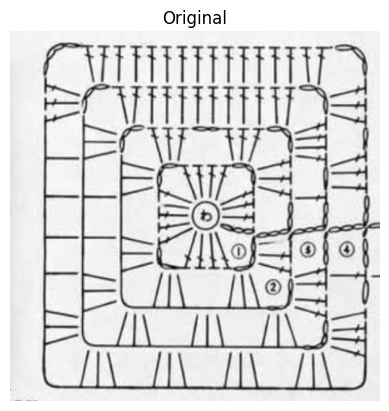

In [102]:
# --- Cell 2: Load image ---
IMG_PATH = "data/raw/easy/2.png"  # change this

img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512))

show(img, "Original")

In [103]:
# --- Cell 3: Find center automatically ---
# use image center (works well for granny squares)

h, w = img.shape
center = (w // 2, h // 2)

print("Center:", center)

Center: (256, 256)


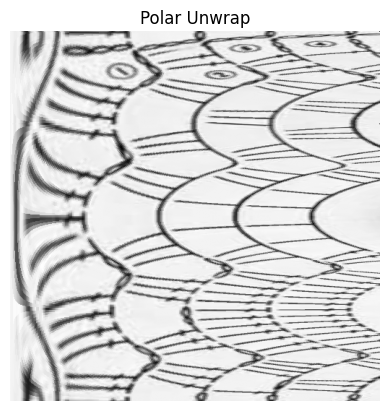

In [104]:
# --- Cell 4: Circular (polar) unwrap ---
# unwrap spiral into rectangle

max_radius = min(center[0], center[1])

polar = cv2.warpPolar(
    img,
    (512, 512),
    center,
    max_radius,
    cv2.WARP_FILL_OUTLIERS
)

show(polar, "Polar Unwrap")

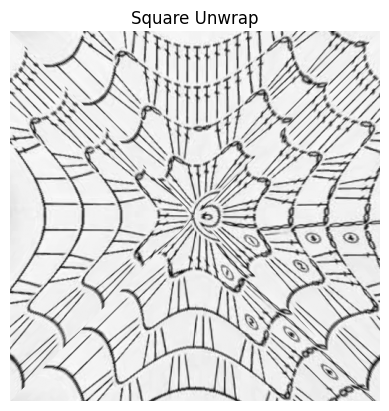

In [105]:
# --- Cell 5: Square-style radial unwrap ---
# custom grid sampling (more structured)

def square_unwrap(img, center, size=512):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    for i in range(size):
        for j in range(size):
            # map square grid → polar
            angle = (i / size) * 2 * np.pi
            radius = (j / size) * min(cx, cy)

            x = int(cx + radius * np.cos(angle))
            y = int(cy + radius * np.sin(angle))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result


# --- Improved square unwrap (layer-based) ---

def square_unwrap_fixed(img, center, size=512):
    h, w = img.shape
    cx, cy = center
    
    result = np.zeros((size, size), dtype=np.uint8)

    max_radius = min(cx, cy)

    for i in range(size):
        for j in range(size):
            
            # map to square coordinates [-1, 1]
            x_norm = (j / size) * 2 - 1
            y_norm = (i / size) * 2 - 1

            # square "radius" (Chebyshev distance)
            r = max(abs(x_norm), abs(y_norm))

            # angle-like parameter along square perimeter
            if abs(x_norm) > abs(y_norm):
                t = y_norm / abs(x_norm)
                if x_norm > 0:
                    angle = t
                else:
                    angle = 2 - t
            else:
                t = x_norm / abs(y_norm) if y_norm != 0 else 0
                if y_norm > 0:
                    angle = 1 - t
                else:
                    angle = 3 + t

            angle = angle / 4  # normalize to [0,1]

            radius = r * max_radius

            theta = angle * 2 * np.pi

            x = int(cx + radius * np.cos(theta))
            y = int(cy + radius * np.sin(theta))

            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]

    return result

square = square_unwrap_fixed(img, center)
show(square, "Square Unwrap")

In [106]:
# --- Cell 6: Save outputs ---
os.makedirs("outputs", exist_ok=True)

cv2.imwrite("outputs/polar.png", polar)
cv2.imwrite("outputs/square.png", square)

print("Saved to outputs/")

Saved to outputs/
